In [1]:
import subprocess
subprocess.run(['pip', 'install', 'grad-cam'], capture_output=True)

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pickle
from torchvision import models, transforms
from PIL import Image
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

print("All imports successful!")

All imports successful!


In [2]:
# Load image classes
with open('data/processed/data_splits.pkl', 'rb') as f:
    image_data = pickle.load(f)
classes = image_data['classes']

# Load ResNet50 with classification head (needed for GradCAM)
model = models.resnet50(weights=None)
model.fc = nn.Linear(2048, len(classes))
model.load_state_dict(torch.load('models/resnet50_finetuned.pth', map_location='cpu'))
model.eval()

print("Model loaded!")
print(f"Classes: {len(classes)}")

# Load a test image
test_image_path = image_data['test_paths'][10]
test_label = classes[image_data['test_labels'][10]]

# Load original image for visualization
orig_img = Image.open(test_image_path).convert('RGB')
orig_img_resized = orig_img.resize((224, 224))
orig_np = np.array(orig_img_resized) / 255.0  # normalize to 0-1 for overlay

# Preprocess for model
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

img_tensor = transform(orig_img).unsqueeze(0)

print(f"\nTest image: {test_image_path.split('/')[-2]}")
print(f"True label: {test_label}")
print(f"Image tensor shape: {img_tensor.shape}")

Model loaded!
Classes: 15

Test image: Tomato_Early_blight
True label: Tomato_Early_blight
Image tensor shape: torch.Size([1, 3, 224, 224])


In [3]:
# Target the last convolutional layer of ResNet50
target_layer = [model.layer4[-1]]

# Generate GradCAM
cam = GradCAM(model=model, target_layers=target_layer)

# Get prediction first
with torch.no_grad():
    outputs = model(img_tensor)
    probs = torch.softmax(outputs, dim=1)
    confidence, predicted = probs.max(1)

predicted_class = classes[predicted.item()]
confidence_pct = round(confidence.item() * 100, 2)

print(f"Predicted: {predicted_class}")
print(f"Confidence: {confidence_pct}%")
print(f"True label: {test_label}")
print(f"Correct: {predicted_class == test_label}")

# Generate heatmap
targets = [ClassifierOutputTarget(predicted.item())]
grayscale_cam = cam(input_tensor=img_tensor, targets=targets)
grayscale_cam = grayscale_cam[0]  # take first image in batch

# Overlay heatmap on original image
visualization = show_cam_on_image(orig_np.astype(np.float32),
                                   grayscale_cam, use_rgb=True)

print(f"\nHeatmap shape: {grayscale_cam.shape}")
print("Grad-CAM generated successfully!")

Predicted: Tomato_Early_blight
Confidence: 100.0%
True label: Tomato_Early_blight
Correct: True

Heatmap shape: (224, 224)
Grad-CAM generated successfully!


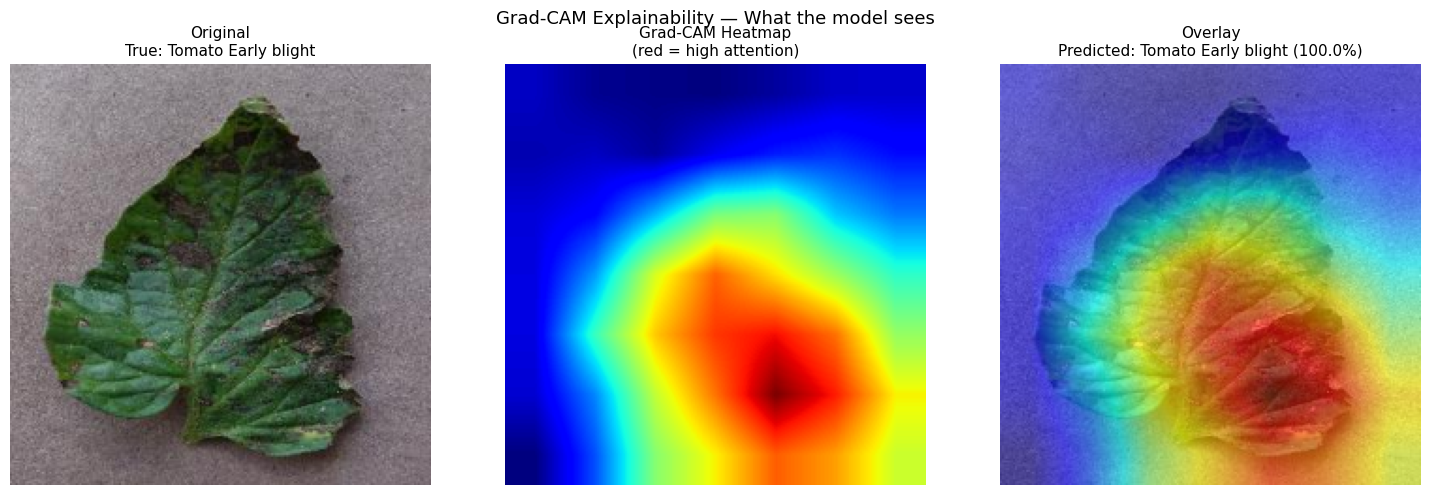

Saved to outputs/gradcam/gradcam_sample.png


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original image
axes[0].imshow(orig_img_resized)
axes[0].set_title(f'Original\nTrue: {test_label.replace("_", " ")}', fontsize=11)
axes[0].axis('off')

# Heatmap only
axes[1].imshow(grayscale_cam, cmap='jet')
axes[1].set_title('Grad-CAM Heatmap\n(red = high attention)', fontsize=11)
axes[1].axis('off')

# Overlay
axes[2].imshow(visualization)
axes[2].set_title(f'Overlay\nPredicted: {predicted_class.replace("_", " ")} ({confidence_pct}%)', fontsize=11)
axes[2].axis('off')

plt.suptitle('Grad-CAM Explainability — What the model sees', fontsize=13)
plt.tight_layout()
plt.savefig('outputs/gradcam/gradcam_sample.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/gradcam/gradcam_sample.png")

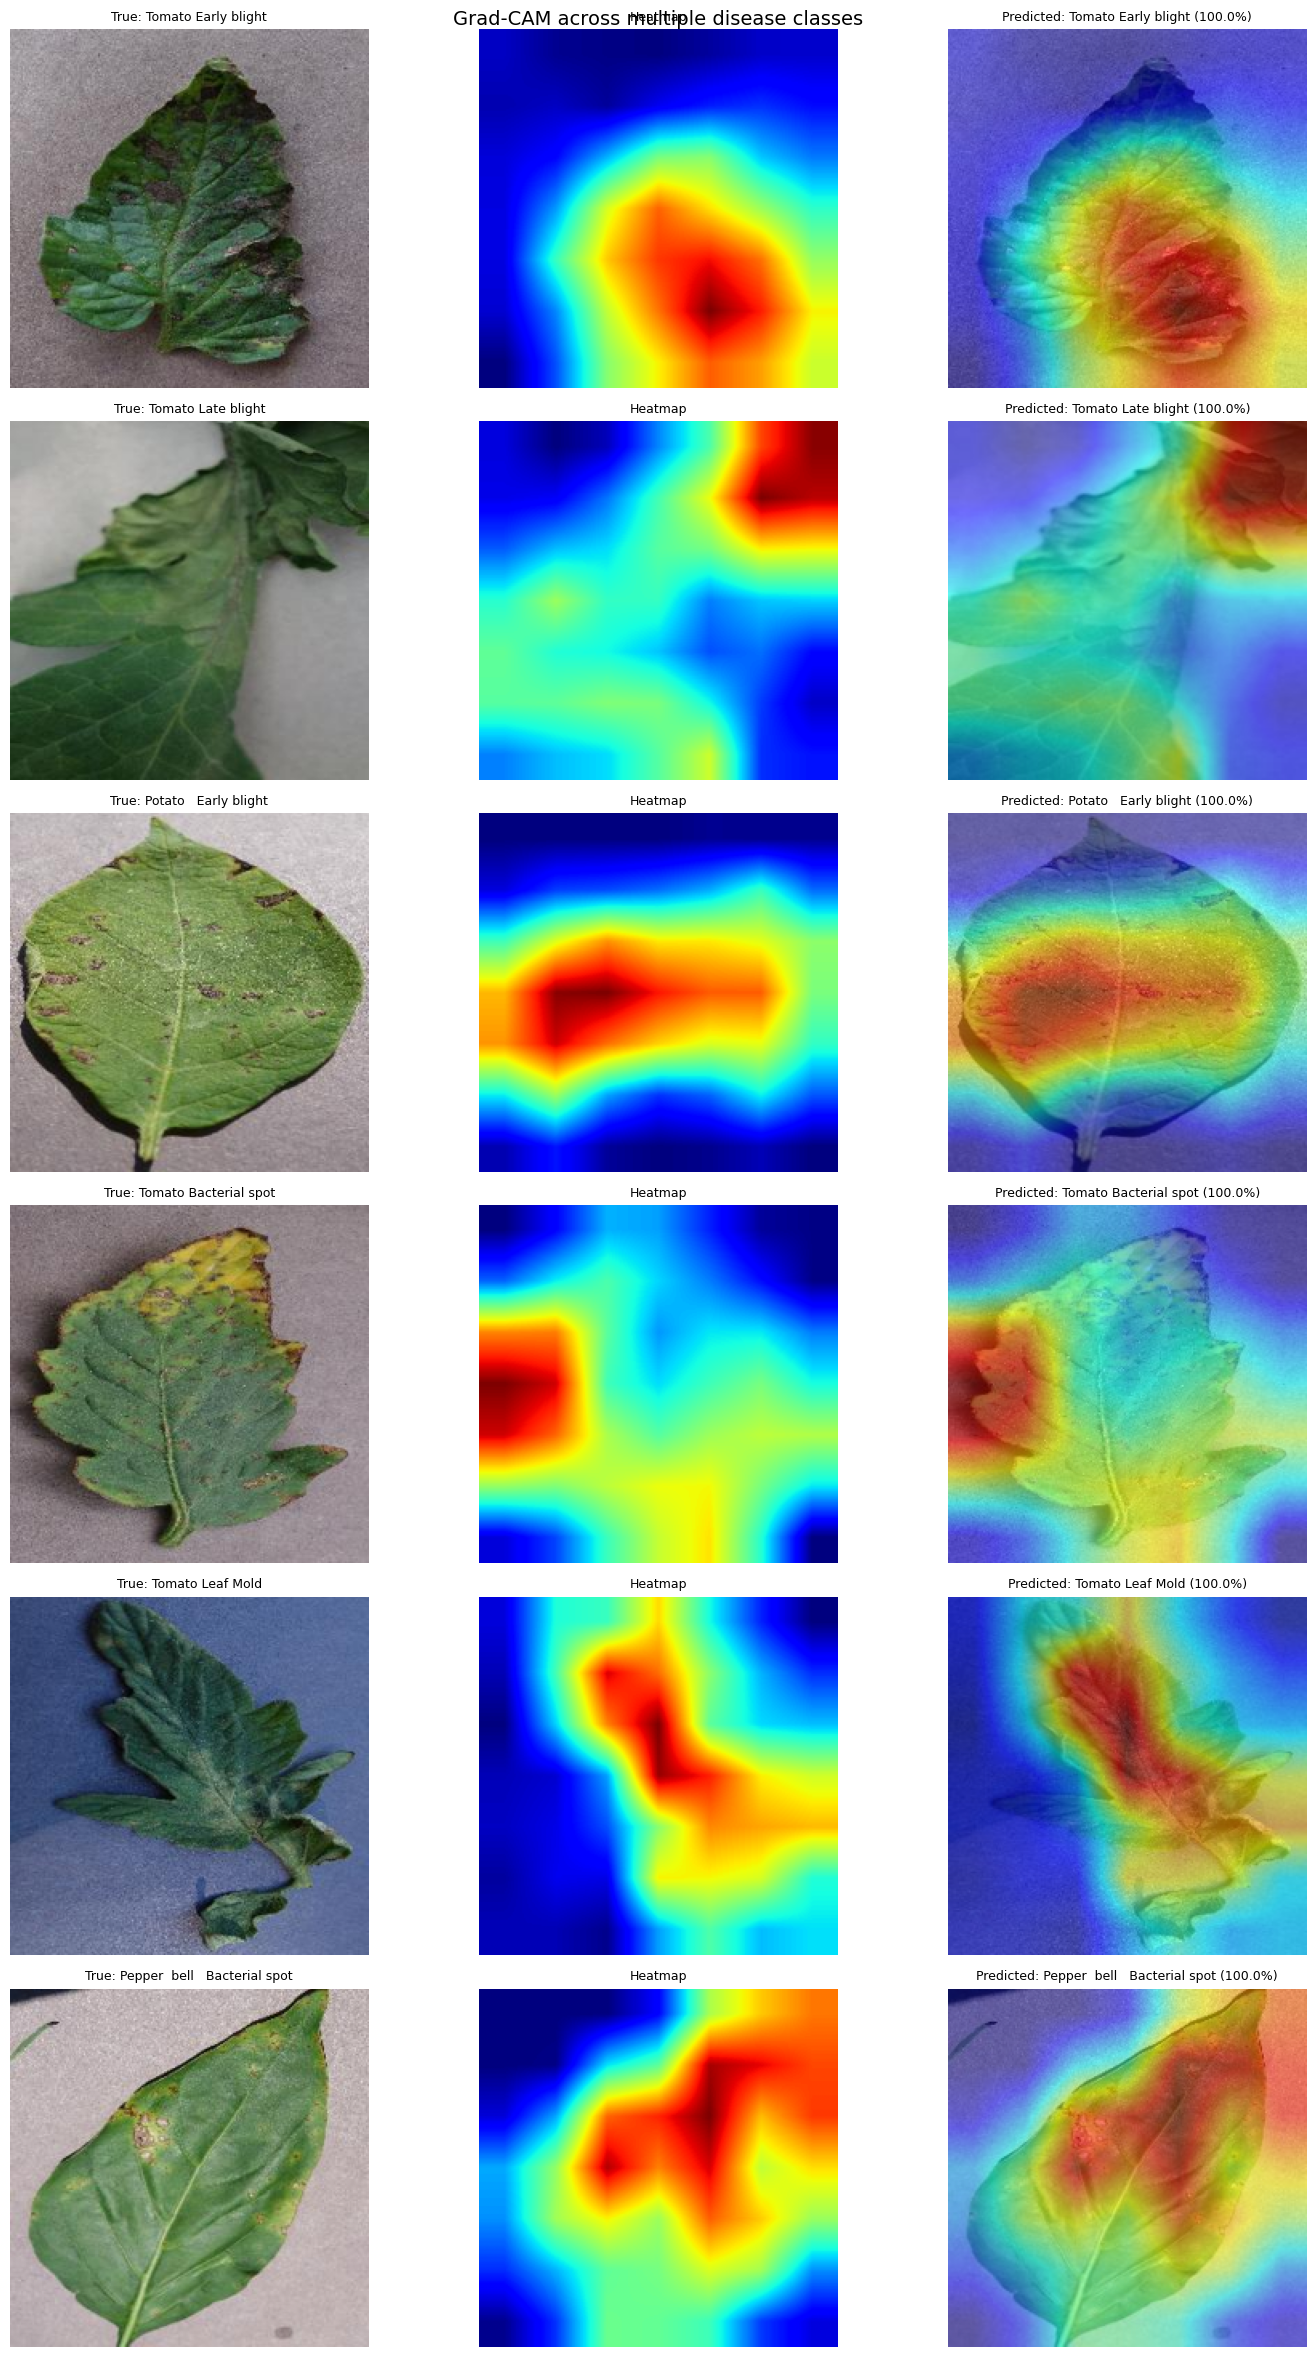

Saved to outputs/gradcam/gradcam_multiclass.png


In [5]:
# Pick one test image from 6 different classes
selected_classes = [
    'Tomato_Early_blight',
    'Tomato_Late_blight', 
    'Potato___Early_blight',
    'Tomato_Bacterial_spot',
    'Tomato_Leaf_Mold',
    'Pepper__bell___Bacterial_spot'
]

fig, axes = plt.subplots(len(selected_classes), 3, figsize=(15, 4*len(selected_classes)))

for row, class_name in enumerate(selected_classes):
    # Find a test image from this class
    class_idx = classes.index(class_name)
    matching = [(p, l) for p, l in zip(image_data['test_paths'], 
                                        image_data['test_labels']) 
                if l == class_idx]
    
    if not matching:
        continue
        
    img_path, label = matching[0]
    
    # Load and preprocess
    orig = Image.open(img_path).convert('RGB')
    orig_resized = orig.resize((224, 224))
    orig_np = np.array(orig_resized) / 255.0
    img_tensor = transform(orig).unsqueeze(0)
    
    # Predict
    with torch.no_grad():
        outputs = model(img_tensor)
        probs = torch.softmax(outputs, dim=1)
        conf, pred = probs.max(1)
    
    pred_class = classes[pred.item()]
    conf_pct = round(conf.item() * 100, 1)
    
    # Generate GradCAM
    grayscale_cam = cam(input_tensor=img_tensor,
                        targets=[ClassifierOutputTarget(pred.item())])
    grayscale_cam = grayscale_cam[0]
    visualization = show_cam_on_image(orig_np.astype(np.float32),
                                       grayscale_cam, use_rgb=True)
    
    # Plot
    axes[row, 0].imshow(orig_resized)
    axes[row, 0].set_title(f'True: {class_name.replace("_", " ")}', fontsize=9)
    axes[row, 0].axis('off')
    
    axes[row, 1].imshow(grayscale_cam, cmap='jet')
    axes[row, 1].set_title('Heatmap', fontsize=9)
    axes[row, 1].axis('off')
    
    axes[row, 2].imshow(visualization)
    axes[row, 2].set_title(f'Predicted: {pred_class.replace("_", " ")} ({conf_pct}%)', fontsize=9)
    axes[row, 2].axis('off')

plt.suptitle('Grad-CAM across multiple disease classes', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/gradcam/gradcam_multiclass.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/gradcam/gradcam_multiclass.png")

In [6]:
new_api = '''import torch
import torch.nn as nn
import numpy as np
import joblib
import json
import pickle
import io
import base64
from torchvision import models, transforms
from PIL import Image
from fastapi import FastAPI, File, UploadFile, HTTPException
from fastapi.middleware.cors import CORSMiddleware
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

app = FastAPI(title="Crop Disease AI", version="1.0")

app.add_middleware(
    CORSMiddleware,
    allow_origins=["*"],
    allow_methods=["*"],
    allow_headers=["*"],
)

# ── Load everything at startup ──
with open("data/processed/data_splits.pkl", "rb") as f:
    image_data = pickle.load(f)
IMAGE_CLASSES = image_data["classes"]

with open("data/treatments.json") as f:
    TREATMENTS = json.load(f)

TRANSFORM = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load ResNet50 — keep full model for GradCAM
RESNET = models.resnet50(weights=None)
RESNET.fc = nn.Linear(2048, len(IMAGE_CLASSES))
RESNET.load_state_dict(torch.load("models/resnet50_finetuned.pth",
                                   map_location="cpu"))
RESNET.eval()

# Feature extractor (no final layer)
EMBEDDING_MODEL = nn.Sequential(*list(RESNET.children())[:-1])
EMBEDDING_MODEL.eval()

# GradCAM on last conv layer
GRAD_CAM = GradCAM(model=RESNET, target_layers=[RESNET.layer4[-1]])

# Fusion MLP
class FusionMLP(nn.Module):
    def __init__(self, input_dim, num_classes):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 512), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.network(x)

FUSION_MODEL = FusionMLP(input_dim=2057, num_classes=15)
FUSION_MODEL.load_state_dict(torch.load("models/fusion_mlp_best.pth",
                                         map_location="cpu"))
FUSION_MODEL.eval()

SCALER = joblib.load("models/tabular_scaler_v2.pkl")

print("All models loaded successfully!")

def image_to_base64(img_array):
    """Convert numpy image array to base64 string."""
    img = Image.fromarray(img_array)
    buffer = io.BytesIO()
    img.save(buffer, format="PNG")
    return base64.b64encode(buffer.getvalue()).decode("utf-8")

@app.get("/")
def root():
    return {"message": "Crop Disease AI API is running!", "version": "1.0"}

@app.get("/health")
def health():
    return {"status": "healthy"}

@app.get("/classes")
def get_classes():
    return {"classes": IMAGE_CLASSES, "total": len(IMAGE_CLASSES)}

@app.post("/predict")
async def predict(
    file: UploadFile = File(...),
    soil_pH: float = 6.5,
    nitrogen: float = 80.0,
    phosphorus: float = 60.0,
    potassium: float = 70.0,
    temperature: float = 28.0,
    humidity: float = 65.0,
    rainfall: float = 120.0,
    crop_age_days: float = 45.0,
    sunlight_hours: float = 7.0
):
    if not file.content_type.startswith("image/"):
        raise HTTPException(status_code=400, detail="File must be an image")

    # Load image
    contents = await file.read()
    import tempfile, os
    suffix = os.path.splitext(file.filename)[-1] or ".jpg"
    with tempfile.NamedTemporaryFile(delete=False, suffix=suffix) as tmp:
        tmp.write(contents)
        tmp_path = tmp.name
    try:
        orig_img = Image.open(tmp_path).convert("RGB")
    except Exception:
        raise HTTPException(status_code=400,
                            detail="Could not read image. Please upload JPG or PNG.")
    finally:
        os.unlink(tmp_path)

    # Preprocess
    orig_resized = orig_img.resize((224, 224))
    orig_np = np.array(orig_resized) / 255.0
    img_tensor = TRANSFORM(orig_img).unsqueeze(0)

    # Get image embedding
    with torch.no_grad():
        embedding = EMBEDDING_MODEL(img_tensor)
        embedding = embedding.squeeze(-1).squeeze(-1).numpy()

    # Preprocess tabular
    tab_values = np.array([[soil_pH, nitrogen, phosphorus, potassium,
                            temperature, humidity, rainfall,
                            crop_age_days, sunlight_hours]])
    tab_scaled = SCALER.transform(tab_values)

    # Fuse and predict
    fused = np.concatenate([embedding, tab_scaled], axis=1)
    fused_tensor = torch.tensor(fused, dtype=torch.float32)

    with torch.no_grad():
        outputs = FUSION_MODEL(fused_tensor)
        probs = torch.softmax(outputs, dim=1)
        confidence, predicted = probs.max(1)

    disease = IMAGE_CLASSES[predicted.item()]
    confidence_pct = round(confidence.item() * 100, 2)

    # Generate GradCAM using ResNet prediction
    with torch.no_grad():
        resnet_out = RESNET(img_tensor)
        _, resnet_pred = resnet_out.max(1)

    grayscale_cam = GRAD_CAM(
        input_tensor=img_tensor,
        targets=[ClassifierOutputTarget(resnet_pred.item())]
    )[0]
    cam_overlay = show_cam_on_image(orig_np.astype(np.float32),
                                    grayscale_cam, use_rgb=True)
    gradcam_b64 = image_to_base64(cam_overlay)

    # Get treatment
    treatment = TREATMENTS.get(disease, {
        "severity": "Unknown",
        "description": "No information available.",
        "treatment": "Consult an agricultural expert.",
        "prevention": "Monitor crop regularly.",
        "urgency": "Consult expert"
    })

    return {
        "disease": disease,
        "confidence": confidence_pct,
        "severity": treatment["severity"],
        "description": treatment["description"],
        "treatment": treatment["treatment"],
        "prevention": treatment["prevention"],
        "urgency": treatment["urgency"],
        "gradcam_image": gradcam_b64
    }
'''

with open('src/api.py', 'w') as f:
    f.write(new_api)

print("src/api.py updated with Grad-CAM!")

src/api.py updated with Grad-CAM!


In [7]:
import requests
import base64
from PIL import Image
import io
import matplotlib.pyplot as plt

# Send request to API
with open('/tmp/test_leaf.jpg', 'rb') as f:
    response = requests.post(
        'http://localhost:8000/predict',
        files={'file': f},
        params={
            'soil_pH': 6.5, 'nitrogen': 80, 'phosphorus': 60,
            'potassium': 70, 'temperature': 28, 'humidity': 65,
            'rainfall': 120, 'crop_age_days': 45, 'sunlight_hours': 7
        }
    )

data = response.json()

# Decode and display GradCAM image
img_bytes = base64.b64decode(data['gradcam_image'])
gradcam_img = Image.open(io.BytesIO(img_bytes))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(Image.open('/tmp/test_leaf.jpg'))
axes[0].set_title('Original image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(gradcam_img)
axes[1].set_title(f'Grad-CAM: {data["disease"]}\nConfidence: {data["confidence"]}%', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('outputs/gradcam/api_gradcam_test.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Disease: {data['disease']}")
print(f"Confidence: {data['confidence']}%")
print(f"Urgency: {data['urgency']}")

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [8]:
print(f"Status code: {response.status_code}")
print(f"Response text: {response.text[:500]}")

Status code: 500
Response text: Internal Server Error


In [9]:
new_api = open('src/api.py').read().replace(
    '    if not file.content_type.startswith("image/"):\n        raise HTTPException(status_code=400, detail="File must be an image")',
    '    if file.content_type and not file.content_type.startswith("image/"):\n        raise HTTPException(status_code=400, detail="File must be an image")'
)

with open('src/api.py', 'w') as f:
    f.write(new_api)

print("src/api.py updated!")

src/api.py updated!


Status code: 200


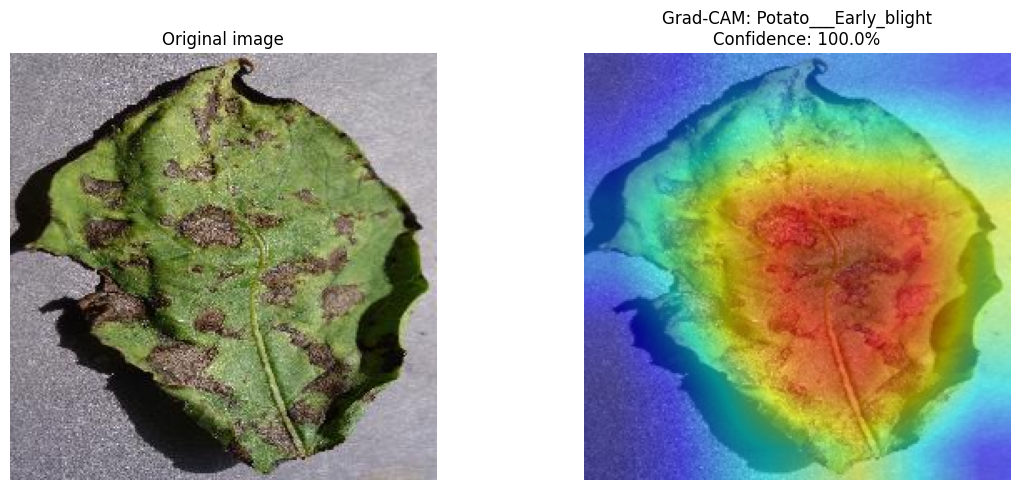

Disease: Potato___Early_blight
Confidence: 100.0%
Urgency: Act within 3-5 days


In [10]:
import requests
import base64
from PIL import Image
import io
import matplotlib.pyplot as plt

# Send request to API
with open('/tmp/test_leaf.jpg', 'rb') as f:
    response = requests.post(
        'http://localhost:8000/predict',
        files={'file': ('test_leaf.jpg', f, 'image/jpeg')},
        params={
            'soil_pH': 6.5, 'nitrogen': 80, 'phosphorus': 60,
            'potassium': 70, 'temperature': 28, 'humidity': 65,
            'rainfall': 120, 'crop_age_days': 45, 'sunlight_hours': 7
        }
    )

print(f"Status code: {response.status_code}")

data = response.json()

# Decode and display GradCAM image
img_bytes = base64.b64decode(data['gradcam_image'])
gradcam_img = Image.open(io.BytesIO(img_bytes))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(Image.open('/tmp/test_leaf.jpg'))
axes[0].set_title('Original image', fontsize=12)
axes[0].axis('off')

axes[1].imshow(gradcam_img)
axes[1].set_title(f'Grad-CAM: {data["disease"]}\nConfidence: {data["confidence"]}%', fontsize=12)
axes[1].axis('off')

plt.tight_layout()
plt.savefig('outputs/gradcam/api_gradcam_test.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Disease: {data['disease']}")
print(f"Confidence: {data['confidence']}%")
print(f"Urgency: {data['urgency']}")